# Support Vector Machine (SVM) from Scratch ⚔️

In this notebook, we implement a **Linear Support Vector Machine (SVM)** classifier using Gradient Descent.

## 📖 Theoretical Background

SVM aims to find a hyperplane that separates classes with the maximum margin.

### 1. The Hypothesis and Margin
For binary classification, labels $y$ must be encoded as $\{-1, 1\}$. The prediction is based on the sign of the linear model:
$$\hat{y} = \text{sign}(Xw - b)$$

### 2. Hinge Loss
The objective is to maximize the margin while penalizing points that fall on the wrong side of the margin. We use **Hinge Loss**:
$$J = \lambda ||w||^2 + \frac{1}{n} \sum_{i=1}^{n} \max(0, 1 - y_i(w \cdot x_i - b))$$

### 3. Gradients
If $y_i(w \cdot x_i - b) \geq 1$, the point is correctly classified and outside the margin. The gradient is just the regularization term:
$$dw = 2\lambda w, \quad db = 0$$

If $y_i(w \cdot x_i - b) < 1$, the point incurs a loss. The gradients are:
$$dw = 2\lambda w - y_ix_i$$
$$db = y_i$$

We update weights iteratively using these gradients.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

np.random.seed(42)

## 🏗️ The Implementation

In [2]:
class SVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iterations = n_iterations
        self.w = None
        self.b = None
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # Encode labels as -1 and 1
        y_ = np.where(y <= 0, -1, 1)
        
        self.w = np.zeros(n_features)
        self.b = 0
        
        for _ in range(self.n_iterations):
            for idx, x_i in enumerate(X):
                condition = y_[idx] * (np.dot(x_i, self.w) - self.b) >= 1
                
                if condition:
                    self.w -= self.lr * (2 * self.lambda_param * self.w)
                else:
                    self.w -= self.lr * (2 * self.lambda_param * self.w - np.dot(x_i, y_[idx]))
                    self.b -= self.lr * y_[idx]
                    
    def predict(self, X):
        approx = np.dot(X, self.w) - self.b
        return np.sign(approx)


## 🧪 Data Generation and Training

In [3]:
X, y = make_blobs(n_samples=250, centers=2, random_state=42, cluster_std=1.2)
y = np.where(y == 0, -1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

clf = SVM(learning_rate=0.001, lambda_param=0.01, n_iterations=1000)
clf.fit(X_train, y_train)
predictions = clf.predict(X_test)

accuracy = np.sum(predictions == y_test) / len(y_test)
print(f"SVM Accuracy: {accuracy * 100:.2f}%")

SVM Accuracy: 100.00%


## 📊 Visualization

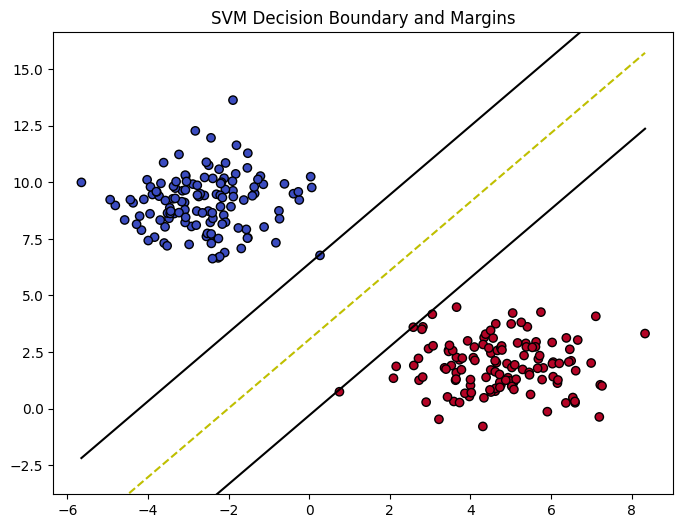

In [4]:
def visualize_svm():
    def get_hyperplane_value(x, w, b, offset):
        return (-w[0] * x + b + offset) / w[1]

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(1,1,1)
    plt.scatter(X[:,0], X[:,1], marker='o', c=y, cmap="coolwarm", edgecolors="k")

    x0_1 = np.amin(X[:,0])
    x0_2 = np.amax(X[:,0])

    x1_1 = get_hyperplane_value(x0_1, clf.w, clf.b, 0)
    x1_2 = get_hyperplane_value(x0_2, clf.w, clf.b, 0)
    x1_1_m = get_hyperplane_value(x0_1, clf.w, clf.b, -1)
    x1_2_m = get_hyperplane_value(x0_2, clf.w, clf.b, -1)
    x1_1_p = get_hyperplane_value(x0_1, clf.w, clf.b, 1)
    x1_2_p = get_hyperplane_value(x0_2, clf.w, clf.b, 1)

    ax.plot([x0_1, x0_2], [x1_1, x1_2], 'y--')
    ax.plot([x0_1, x0_2], [x1_1_m, x1_2_m], 'k')
    ax.plot([x0_1, x0_2], [x1_1_p, x1_2_p], 'k')

    x1_min = np.amin(X[:,1])
    x1_max = np.amax(X[:,1])
    ax.set_ylim([x1_min - 3, x1_max + 3])
    plt.title("SVM Decision Boundary and Margins")
    plt.show()

visualize_svm()

## 📊 Additional Visualizations

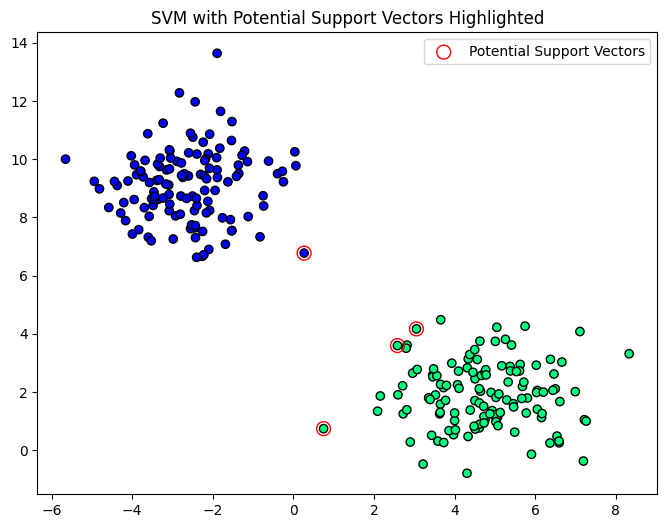

In [5]:

# 1. Margin and Support Vectors
# Since we already have a decision boundary, let's highlight the support vectors.
# Our scratch model might not explicitly store indices of SVs, but we can infer them.

y_mapped = np.where(y <= 0, -1, 1)
z = np.dot(X, clf.w) - clf.b
distances = y_mapped * z
# Points near the margin (distance ~ 1)
sv_indices = np.where(np.abs(distances - 1) < 0.1)[0]

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='winter', edgecolors='k')
plt.scatter(X[sv_indices, 0], X[sv_indices, 1], facecolors='none', edgecolors='r', s=100, label='Potential Support Vectors')
plt.title('SVM with Potential Support Vectors Highlighted')
plt.legend()
plt.show()


## 🔬 Kernel Comparison (Linear vs Polynomial vs RBF)
This section compares how different SVM kernels shape decision boundaries and test accuracy on the current dataset.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

kernels = [
    ("Linear", SVC(kernel='linear', C=1.0)),
    ("Polynomial (degree=3)", SVC(kernel='poly', degree=3, C=1.0, gamma='scale')),
    ("RBF", SVC(kernel='rbf', C=1.0, gamma='scale'))
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, kernels):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, zz, alpha=0.25, cmap='coolwarm')
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=30)
    ax.set_title(f"{name}\nAccuracy: {acc * 100:.2f}%")
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('Kernel Comparison on Blob Dataset', y=1.05)
plt.tight_layout()
plt.show()

## 🌙 Nonlinear Example: Why Kernel Choice Matters
On nonlinear data, linear SVM can underfit, while polynomial and RBF kernels can capture curved boundaries more effectively.

In [ ]:
from sklearn.datasets import make_moons

X_moon, y_moon = make_moons(n_samples=300, noise=0.2, random_state=42)
X_m_train, X_m_test, y_m_train, y_m_test = train_test_split(
    X_moon, y_moon, test_size=0.25, random_state=42
)

moon_kernels = [
    ("Linear", SVC(kernel='linear', C=1.0)),
    ("Polynomial (degree=3)", SVC(kernel='poly', degree=3, C=1.0, gamma='scale')),
    ("RBF", SVC(kernel='rbf', C=1.0, gamma='scale'))
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, model) in zip(axes, moon_kernels):
    model.fit(X_m_train, y_m_train)
    y_pred = model.predict(X_m_test)
    acc = accuracy_score(y_m_test, y_pred)

    x_min, x_max = X_moon[:, 0].min() - 0.5, X_moon[:, 0].max() + 0.5
    y_min, y_max = X_moon[:, 1].min() - 0.5, X_moon[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    zz = model.predict(grid).reshape(xx.shape)

    ax.contourf(xx, yy, zz, alpha=0.25, cmap='coolwarm')
    ax.scatter(X_moon[:, 0], X_moon[:, 1], c=y_moon, cmap='coolwarm', edgecolors='k', s=20)
    ax.set_title(f"{name}\nAccuracy: {acc * 100:.2f}%")
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

plt.suptitle('Kernel Comparison on Nonlinear Moons Dataset', y=1.05)
plt.tight_layout()
plt.show()

## 🎓 Senior ML Insights: Support Vectors and Margins
Visualizing the decision boundary along with the support vectors and the margin.

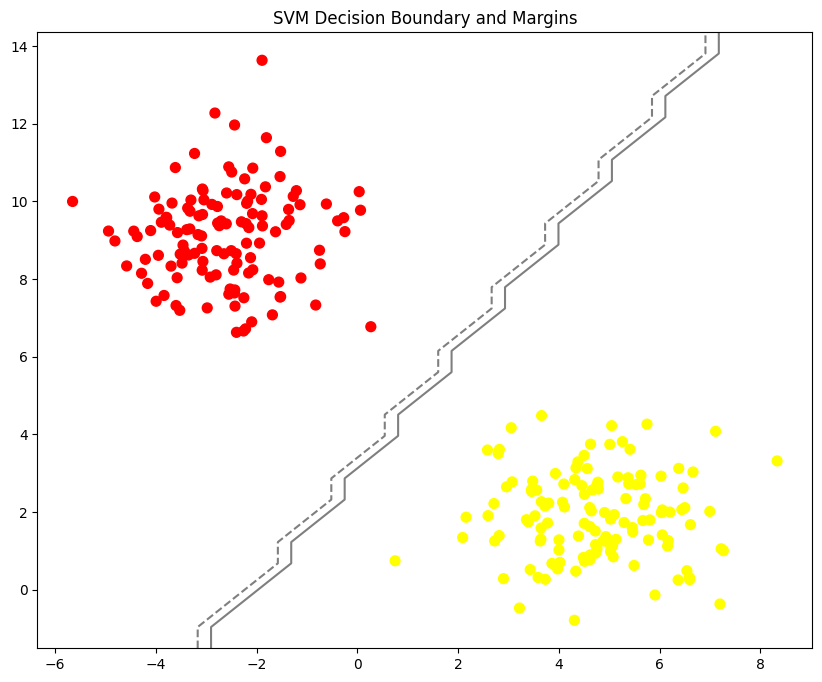

In [8]:

# 1. Decision Boundary with Margins
def plot_svc_decision_function(model, ax=None):
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.predict(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

plt.figure(figsize=(10, 8))
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='autumn')
plot_svc_decision_function(clf)
plt.title("SVM Decision Boundary and Margins")
plt.show()
